SALES DATA ANALYSIS PROJECT

Importing all the libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading and Checking data

In [6]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df['Sales'].sum()

np.float64(2261536.7827000003)

Sales by Category Analysis

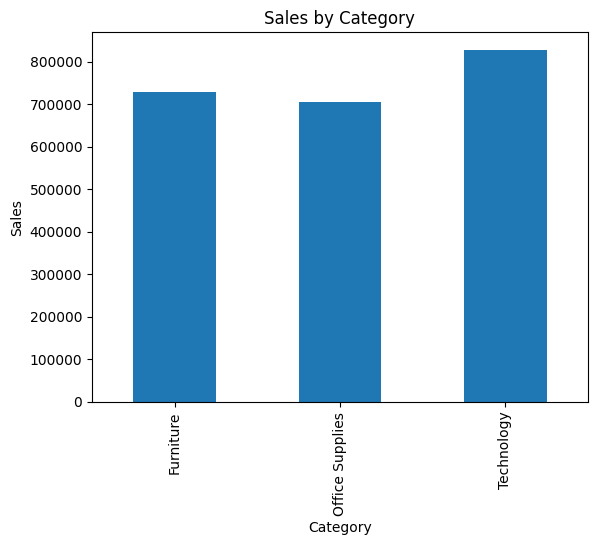

In [ ]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

SELECT Category, SUM(Sales)
FROM superstore
GROUP BY Category;

 Visualization using Seaborn

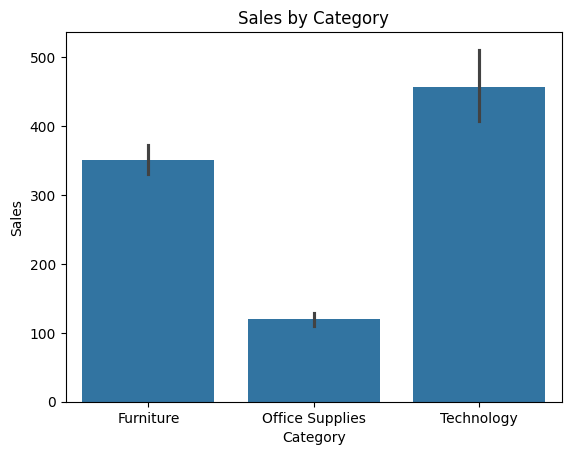

In [ ]:
sns.barplot(x='Category', y='Sales', data=df)

plt.title("Sales by Category")
plt.show()

Some categories generate significantly higher sales than others.

Monthly Sales Trend Analysis

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)


In [ ]:
df['Month'] = df['Order Date'].dt.month

Monthly sales analysis helps identify seasonal business trends.

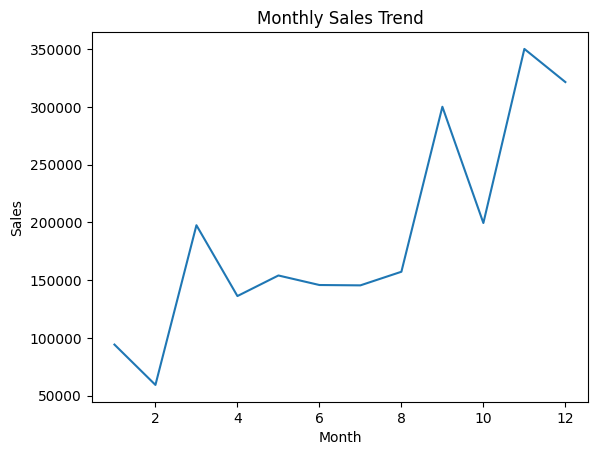

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

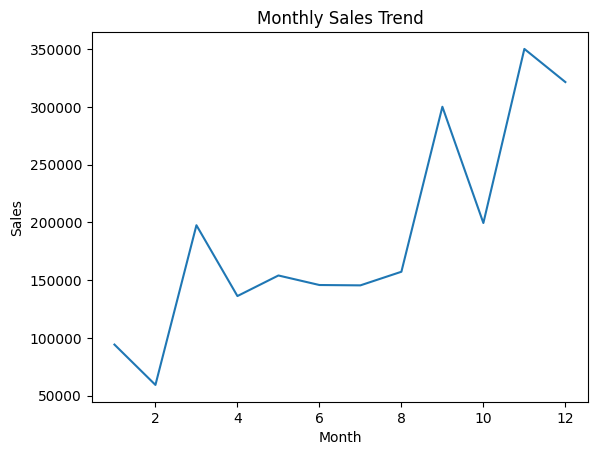

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

sns.lineplot(x='Month', y='Sales', data=monthly_sales)

plt.title("Monthly Sales Trend")
plt.show()

Sales vary across different months, indicating seasonal purchasing behavior.

SELECT MONTH(Order_Date), SUM(Sales)
FROM superstore
GROUP BY MONTH(Order_Date);

Identifying top-selling products helps understand which items drive the most revenue.

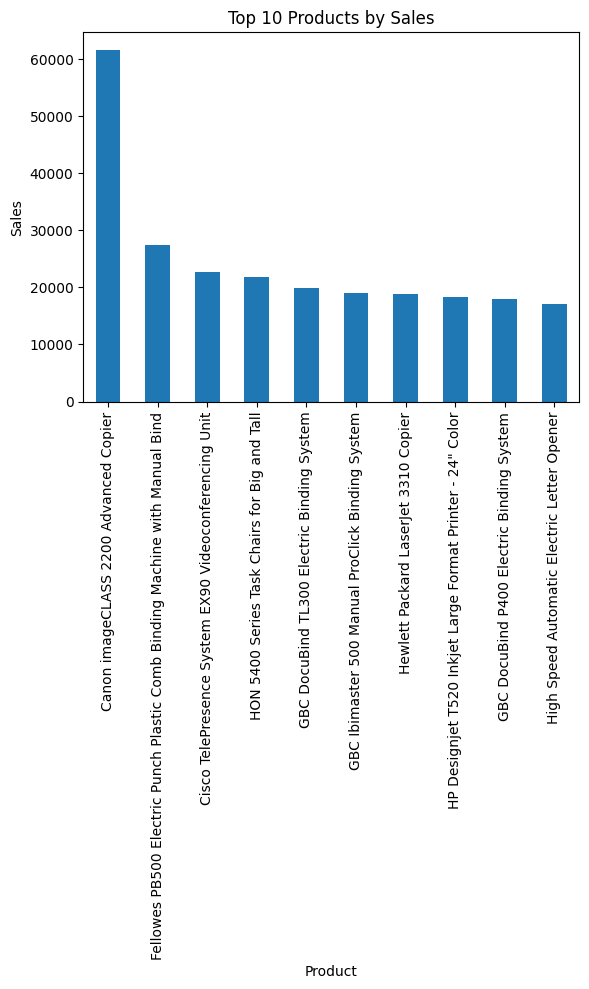

In [7]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

A small number of products contribute significantly to total business revenue.

Regional analysis helps identify areas with stronger sales performance.

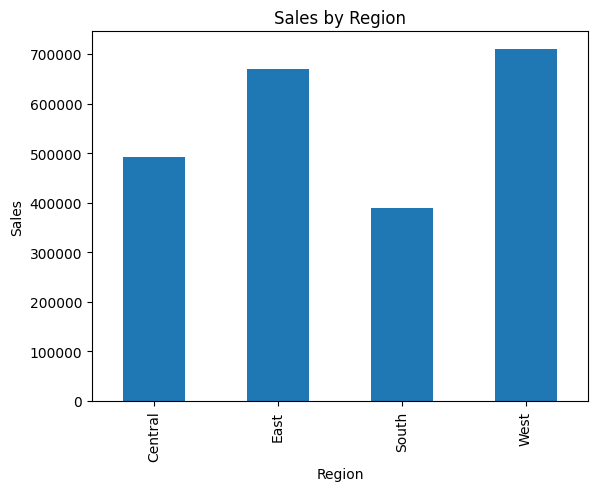

In [8]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

Some regions generate significantly higher sales than others.